In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set default style
sns.set(style="whitegrid")

In [4]:
# Load Dataset
data = pd.read_csv('aqi_data.csv')
# Display basic info
print("✔ Dataset Loaded Successfully\n")

✔ Dataset Loaded Successfully



In [5]:

print("Total Rows:", data.shape[0])
print("Total Columns:", data.shape[1])

Total Rows: 5377
Total Columns: 15


In [6]:
print("\n First 5 Rows of the Dataset:")
display(data.head())


 First 5 Rows of the Dataset:


,rank,city,avg,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,1,"Begusarai, India",223,413,337,250,258,209,205,131,115,100,114,298,249
1,2,"Patna, India",212,354,297,225,230,169,183,82,100,84,136,402,277
2,3,"Saharsa, India",207,418,344,238,220,167,149,85,93,91,110,282,292
3,4,"New Delhi, India",205,325,244,167,181,175,124,70,110,91,210,405,352
4,5,"Noida, India",201,304,212,154,187,176,129,70,125,118,237,367,338


In [7]:
print("\n Dataset Info:")
print(data.info())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5377 entries, 0 to 5376
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rank    5377 non-null   int64 
 1   city    5377 non-null   object
 2   avg     5377 non-null   int64 
 3   jan     5377 non-null   object
 4   feb     5377 non-null   object
 5   mar     5377 non-null   object
 6   apr     5377 non-null   object
 7   may     5377 non-null   object
 8   jun     5377 non-null   object
 9   jul     5377 non-null   object
 10  aug     5377 non-null   object
 11  sep     5377 non-null   object
 12  oct     5377 non-null   object
 13  nov     5377 non-null   object
 14  dec     5377 non-null   object
dtypes: int64(2), object(13)
memory usage: 630.2+ KB
None


In [8]:
# Convert monthly columns to numeric (ignore errors)
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
for m in months:
    data[m] = pd.to_numeric(data[m], errors='coerce')

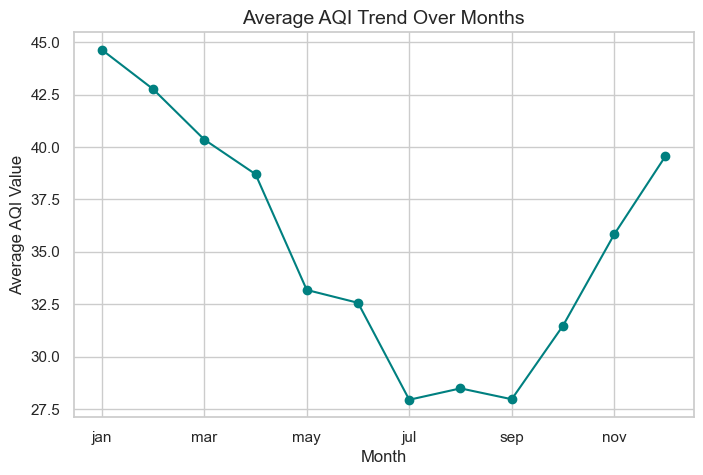

In [9]:
plt.figure(figsize=(8,5))
avg_months = data[months].mean()
avg_months.plot(marker='o', color='teal')
plt.title("Average AQI Trend Over Months", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average AQI Value")
plt.grid(True)
plt.show()

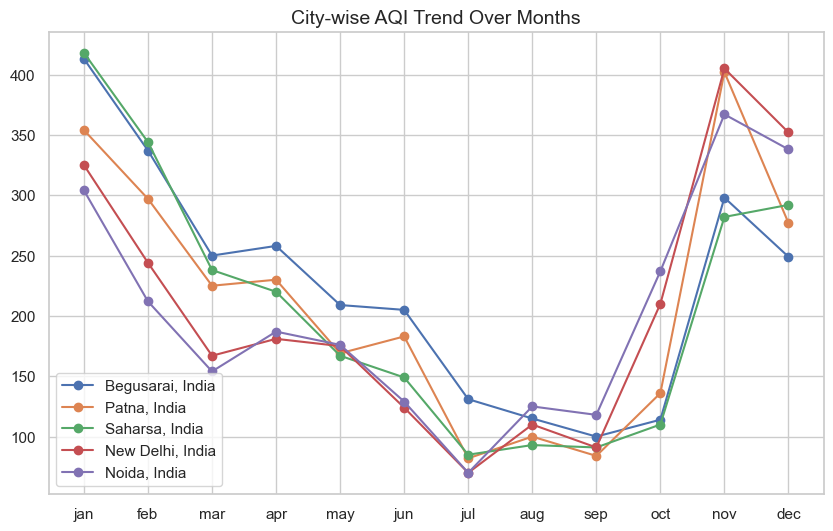

In [10]:
plt.figure(figsize=(10,6))
for i in range(5): # first 5 cities only
    plt.plot(months, data.loc[i, months], marker='o', label=data.loc[i, 'city'])
plt.title("City-wise AQI Trend Over Months", fontsize=14)
plt.legend()
plt.show()

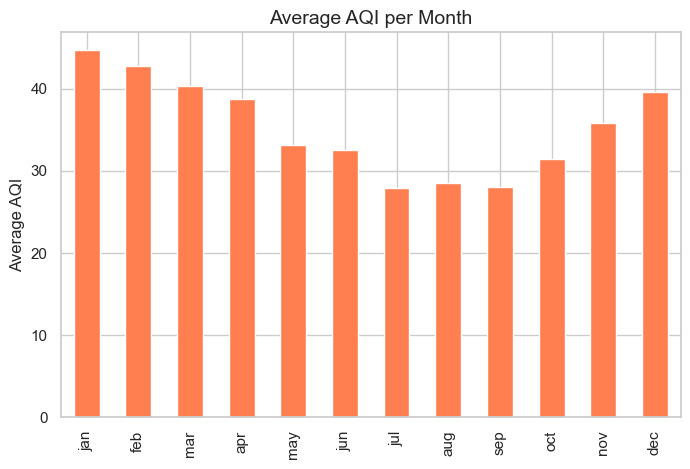

In [11]:
plt.figure(figsize=(8,5))
avg_months.plot(kind='bar', color='coral')
plt.title("Average AQI per Month", fontsize=14)
plt.ylabel("Average AQI")
plt.show()

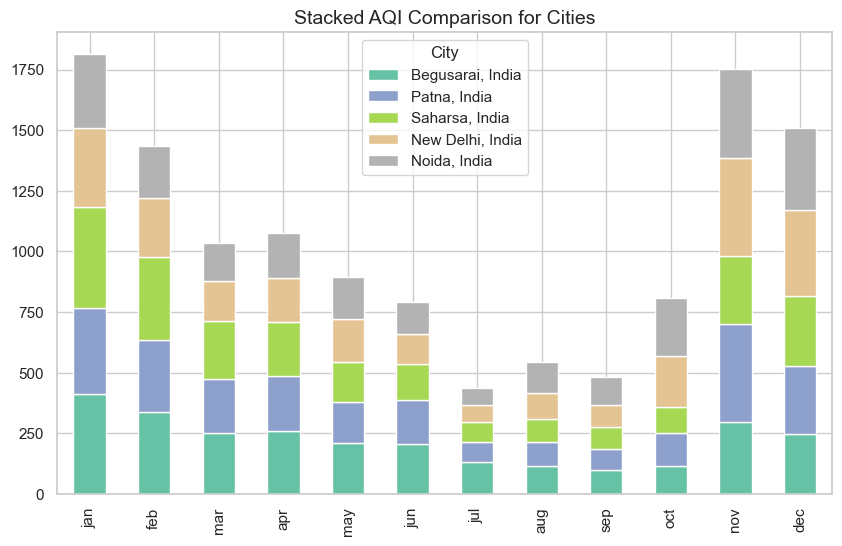

In [12]:
subset = data.head(5)
subset.set_index('city')[months].T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title("Stacked AQI Comparison for Cities", fontsize=14)
plt.legend(title="City")
plt.show()

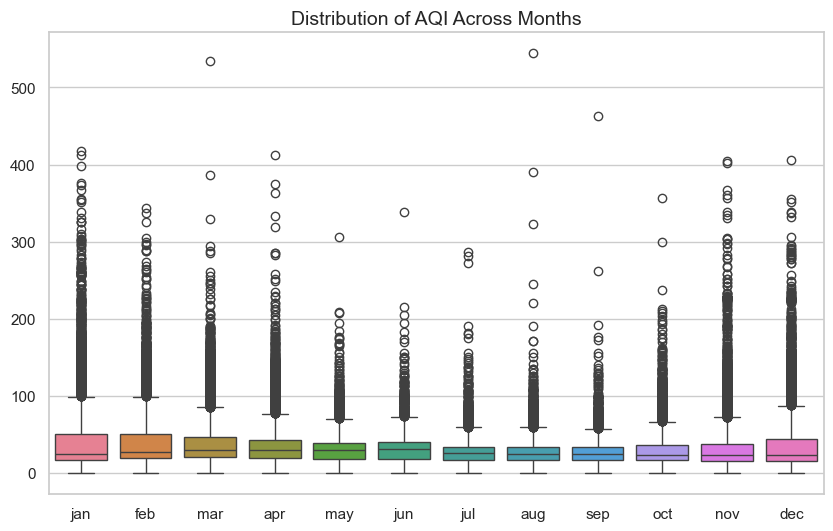

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[months])
plt.title("Distribution of AQI Across Months", fontsize=14)
plt.show()

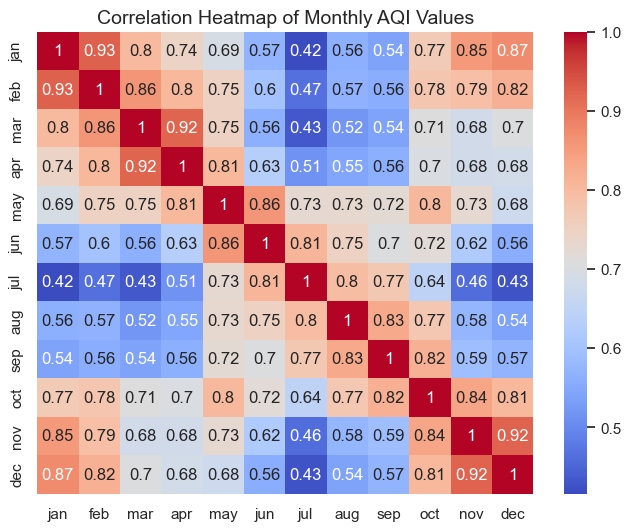

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(data[months].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Monthly AQI Values", fontsize=14)
plt.show()

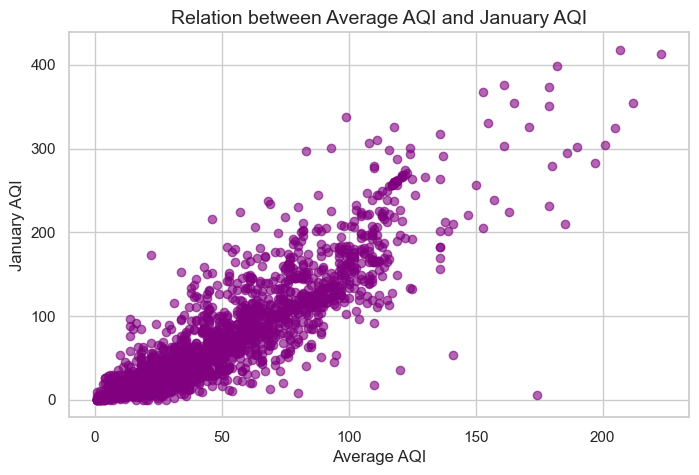

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(data['avg'], data['jan'], color='purple', alpha=0.6)
plt.title("Relation between Average AQI and January AQI", fontsize=14)
plt.xlabel("Average AQI")
plt.ylabel("January AQI")
plt.show()

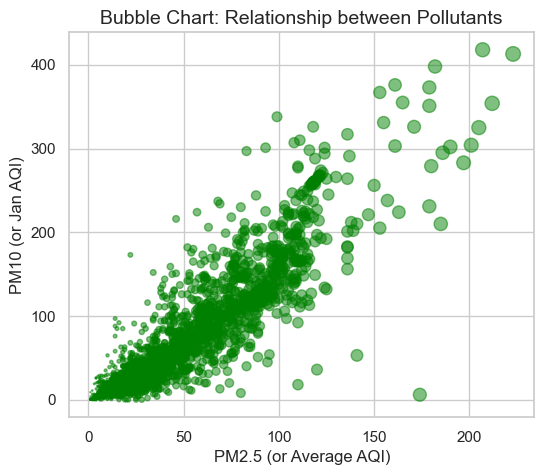

In [16]:
plt.figure(figsize=(6,5))
plt.scatter(data['avg'], 
            data['jan'], 
            s=data['avg']*0.5, 
            alpha=0.5, 
            c='green')
plt.title("Bubble Chart: Relationship between Pollutants", fontsize=14)
plt.xlabel("PM2.5 (or Average AQI)")
plt.ylabel("PM10 (or Jan AQI)")
plt.show()